In [1]:
import numpy as np
from numpy.typing import NDArray
from typing import Callable
import matplotlib.pyplot as plt

In [2]:
def conjugate_gradient_quad(
    A: NDArray[np.float64],
    b: NDArray[np.float64],
    x0: NDArray[np.float64],
    tol: float = 1e-10
) -> tuple[NDArray[np.float64], list[NDArray[np.float64]]]:

    x_current = x0.copy()
    gradient_current = A @ x_current - b
    direction = -gradient_current

    trajectory = [x_current.copy()]

    while True:
        if np.linalg.norm(gradient_current) < tol:
            break

        step_size = (gradient_current @ gradient_current) / (direction @ A @ direction)

        x_current = x_current + step_size * direction
        trajectory.append(x_current.copy())

        gradient_next = A @ x_current - b

        beta = (gradient_next @ gradient_next) / (gradient_current @ gradient_current)

        direction = -gradient_next + beta * direction
        gradient_current = gradient_next

    return x_current, trajectory

n=10, κ=100.0, itérations=12
Erreur finale ||x - x*|| = 2.66e-12


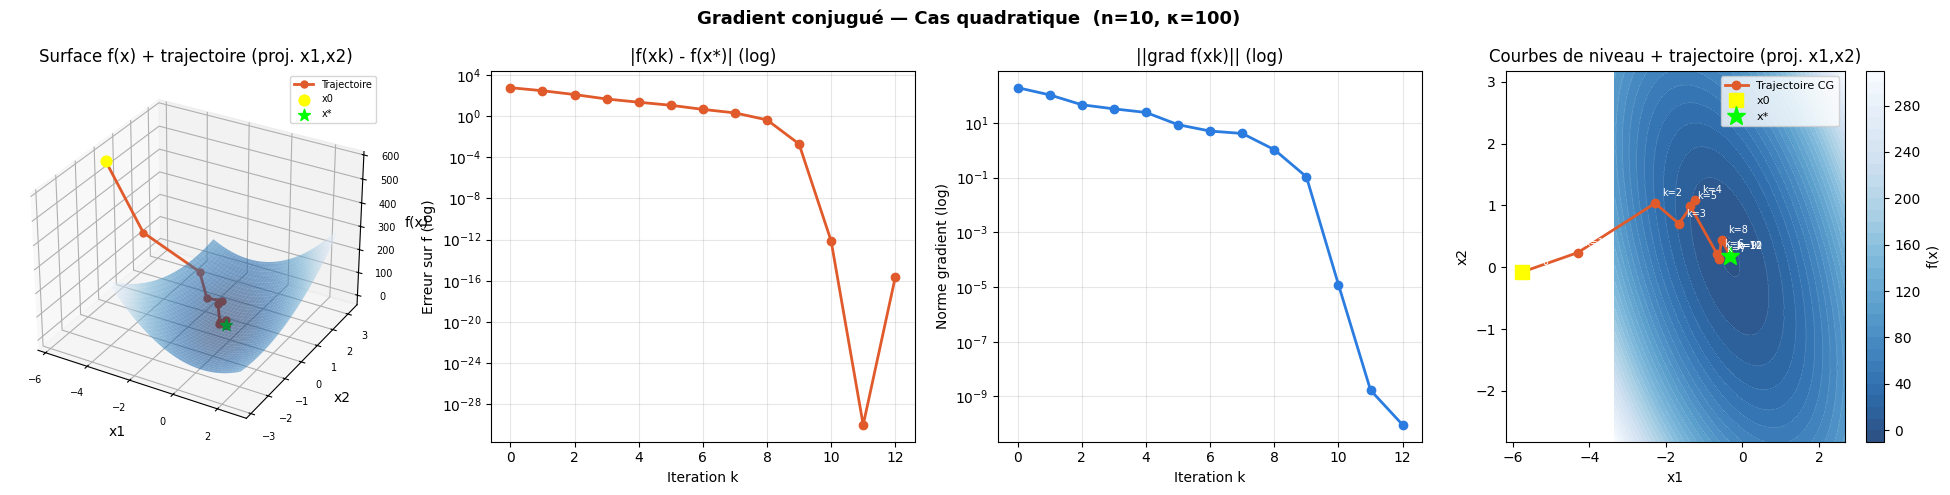

In [3]:
# --- Problème test : n=10, matrice mal conditionnée (κ ≈ 100) ---
np.random.seed(42)
n = 10
eigenvalues = np.array([1, 2, 3, 5, 8, 13, 21, 34, 55, 100], dtype=float)
Q, _ = np.linalg.qr(np.random.randn(n, n))
A = Q @ np.diag(eigenvalues) @ Q.T
b = np.random.randn(n)
x0 = np.random.randn(n) * 3

x_star, trajectory = conjugate_gradient_quad(A, b, x0)
trajectory = np.array(trajectory)
x_exact = np.linalg.solve(A, b)

f = lambda x: 0.5 * x @ A @ x - b @ x
f_star    = f(x_exact)
f_vals    = [f(x) for x in trajectory]
grad_norms = [np.linalg.norm(A @ x - b) for x in trajectory]

print(f"n={n}, κ={np.linalg.cond(A):.1f}, itérations={len(trajectory)-1}")
print(f"Erreur finale ||x - x*|| = {np.linalg.norm(trajectory[-1] - x_exact):.2e}")

# --- Visualisation ---
fig = plt.figure(figsize=(20, 5))
fig.suptitle(f"Gradient conjugué — Cas quadratique  (n={n}, κ={np.linalg.cond(A):.0f})",
             fontsize=13, fontweight="bold")

# Surface 3D projetée sur les 2 premières composantes
ax1 = fig.add_subplot(1, 4, 1, projection="3d")
v1 = np.linspace(x_exact[0]-3, x_exact[0]+3, 80)
v2 = np.linspace(x_exact[1]-3, x_exact[1]+3, 80)
V1, V2 = np.meshgrid(v1, v2)
Z3d = np.zeros_like(V1)
for i in range(V1.shape[0]):
    for j in range(V1.shape[1]):
        xv = x_exact.copy(); xv[0] = V1[i,j]; xv[1] = V2[i,j]
        Z3d[i,j] = f(xv)
ax1.plot_surface(V1, V2, Z3d, cmap="Blues_r", alpha=0.55, linewidth=0, antialiased=True)
traj_z = np.array([f(x) for x in trajectory])
ax1.plot(trajectory[:,0], trajectory[:,1], traj_z, "o-", color="#e05a2b", lw=2, ms=5, label="Trajectoire")
ax1.scatter([trajectory[0,0]], [trajectory[0,1]], [traj_z[0]], color="yellow", s=60, label="x0")
ax1.scatter([trajectory[-1,0]], [trajectory[-1,1]], [traj_z[-1]], color="lime", s=80, marker="*", label="x*")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2"); ax1.set_zlabel("f(x)")
ax1.set_title("Surface f(x) + trajectoire (proj. x1,x2)")
ax1.legend(fontsize=7); ax1.tick_params(labelsize=7)

# Convergence f(xk) - f(x*)
ax2 = fig.add_subplot(1, 4, 2)
ax2.semilogy(range(len(f_vals)), [abs(fv - f_star) + 1e-30 for fv in f_vals],
             "o-", color="#e05a2b", lw=2)
ax2.set_title("|f(xk) - f(x*)| (log)"); ax2.set_xlabel("Iteration k")
ax2.set_ylabel("Erreur sur f (log)"); ax2.grid(True, alpha=0.3)

# Norme du gradient
ax3 = fig.add_subplot(1, 4, 3)
ax3.semilogy(range(len(grad_norms)), grad_norms, "o-", color="#2b7ce0", lw=2)
ax3.set_title("||grad f(xk)|| (log)"); ax3.set_xlabel("Iteration k")
ax3.set_ylabel("Norme gradient (log)"); ax3.grid(True, alpha=0.3)

# Courbe de niveau
ax4 = fig.add_subplot(1, 4, 4)

# Grille sur les 2 premières composantes (les autres fixées à x*)
v1 = np.linspace(x_exact[0]-3, x_exact[0]+3, 200)
v2 = np.linspace(x_exact[1]-3, x_exact[1]+3, 200)
V1, V2 = np.meshgrid(v1, v2)
Z_contour = np.zeros_like(V1)
for i in range(V1.shape[0]):
    for j in range(V1.shape[1]):
        xv = x_exact.copy(); xv[0] = V1[i,j]; xv[1] = V2[i,j]
        Z_contour[i,j] = f(xv)

cp = ax4.contourf(V1, V2, Z_contour, levels=30, cmap="Blues_r", alpha=0.85)
ax4.contour(V1, V2, Z_contour, levels=30, colors="white", linewidths=0.4, alpha=0.4)
plt.colorbar(cp, ax=ax4, label="f(x)")

# Trajectoire itération par itération
ax4.plot(trajectory[:, 0], trajectory[:, 1], "o-", color="#e05a2b",
         lw=2, ms=6, label="Trajectoire CG")
ax4.plot(trajectory[0, 0], trajectory[0, 1], "s", color="yellow", ms=10, label="x0")
ax4.plot(trajectory[-1, 0], trajectory[-1, 1], "*", color="lime", ms=14, label="x*")

# Annoter chaque point avec le numéro d'itération
for k, xk in enumerate(trajectory):
    ax4.annotate(f"k={k}", (xk[0], xk[1]), textcoords="offset points",
                 xytext=(5, 5), fontsize=7, color="white")

ax4.set_title("Courbes de niveau + trajectoire (proj. x1,x2)")
ax4.set_xlabel("x1"); ax4.set_ylabel("x2")
ax4.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
def armijo(
    f: Callable[[NDArray[np.float64]], float],
    gradient_current: NDArray[np.float64],
    x_current: NDArray[np.float64],
    direction: NDArray[np.float64],
    alpha: float = 0.3,
    beta: float = 0.4
) -> float:
    step_size = 1.0
    while f(x_current + step_size * direction) > f(x_current) + alpha * step_size * (gradient_current @ direction):
        step_size *= beta
    return step_size


def conjugate_gradient(
    f: Callable[[NDArray[np.float64]], float],
    grad_f: Callable[[NDArray[np.float64]], NDArray[np.float64]],
    x0: NDArray[np.float64],
    alpha: float = 0.3,
    beta: float = 0.4,
    tol: float = 1e-6,
    max_iter: int = 1000,
) -> tuple[NDArray[np.float64], list[NDArray[np.float64]]]:

    x_current = x0.copy()
    gradient_current = grad_f(x_current)
    direction = -gradient_current

    trajectory = [x_current.copy()]

    while True:
        if np.linalg.norm(gradient_current) < tol:
            break
        if len(trajectory) > max_iter:
            break

        step_size = armijo(f, gradient_current, x_current, direction, alpha, beta)

        x_current = x_current + step_size * direction
        trajectory.append(x_current.copy())

        gradient_next = grad_f(x_current)

        beta_k = ((gradient_next - gradient_current) @ gradient_next) / (gradient_current @ gradient_current)

        direction = -gradient_next + beta_k * direction
        gradient_current = gradient_next

    return x_current, trajectory

Polak-Ribiere   : 53 iterations, x* = [1.00000071 1.00000143]


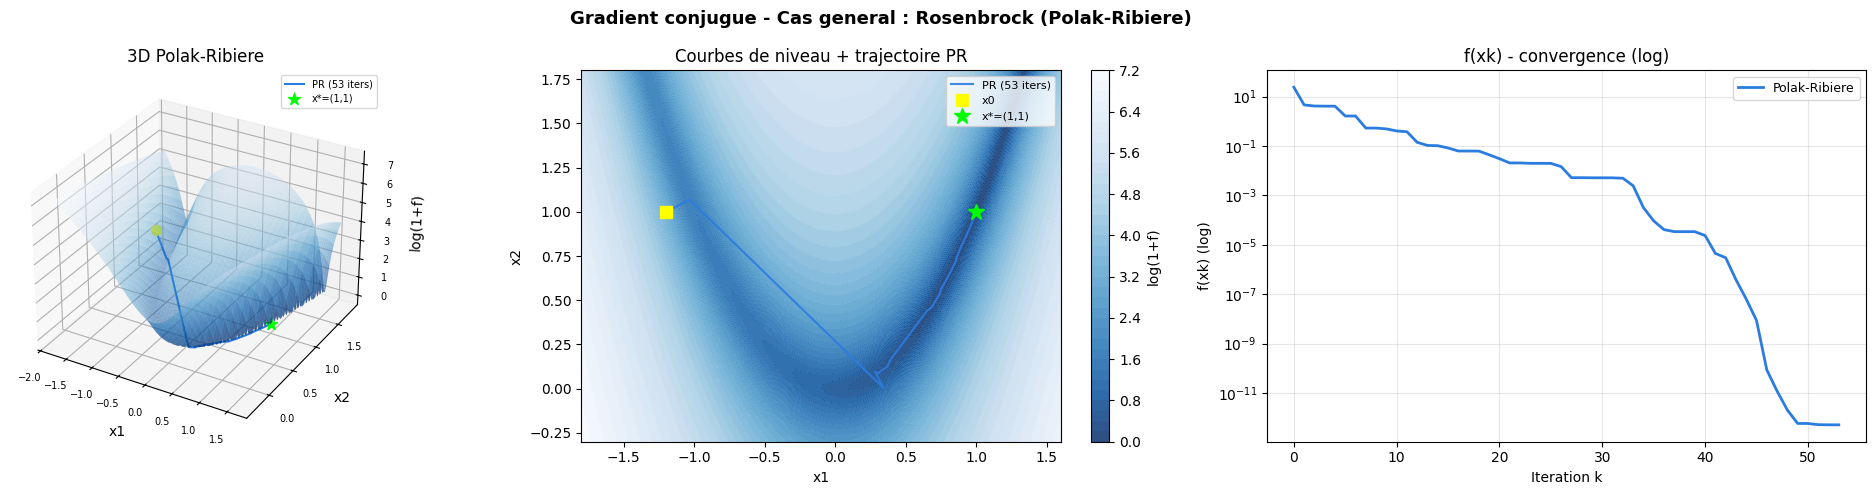

In [5]:
# --- Fonction test : Rosenbrock f(x,y) = (1-x)^2 + 100(y-x^2)^2 ---
f_rb    = lambda x: (1-x[0])**2 + 100*(x[1]-x[0]**2)**2
grad_rb = lambda x: np.array([
    -2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2),
     200*(x[1]-x[0]**2)
])
x0 = np.array([-1.2, 1.0])

x_pr, traj_pr = conjugate_gradient(f_rb, grad_rb, x0)
traj_pr = np.array(traj_pr)

f_vals_pr = [f_rb(x) for x in traj_pr]

print(f"Polak-Ribiere   : {len(traj_pr)-1} iterations, x* = {x_pr}")

# --- Grille Rosenbrock ---
r1 = np.linspace(-1.8, 1.6, 200)
r2 = np.linspace(-0.3, 1.8, 200)
R1, R2 = np.meshgrid(r1, r2)
Z_rb = (1-R1)**2 + 100*(R2-R1**2)**2

fig = plt.figure(figsize=(20, 5))
fig.suptitle("Gradient conjugue - Cas general : Rosenbrock (Polak-Ribiere)",
             fontsize=13, fontweight="bold")

# --- Subplot 1 : 3D Polak-Ribiere ---
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.plot_surface(R1, R2, np.log1p(Z_rb), cmap="Blues_r", alpha=0.5, linewidth=0)
tz_pr = np.log1p(np.array([f_rb(x) for x in traj_pr]))
ax1.plot(traj_pr[:,0], traj_pr[:,1], tz_pr, "-", color="#2b7ce0", lw=1.5,
         label=f"PR ({len(traj_pr)-1} iters)")
ax1.scatter([x0[0]], [x0[1]], [tz_pr[0]], color="yellow", s=50)
ax1.scatter([1], [1], [0], color="lime", s=80, marker="*", label="x*=(1,1)")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2"); ax1.set_zlabel("log(1+f)")
ax1.set_title("3D Polak-Ribiere"); ax1.legend(fontsize=7); ax1.tick_params(labelsize=7)

# --- Subplot 2 : courbes de niveau + trajectoire ---
ax2 = fig.add_subplot(1, 3, 2)
cp = ax2.contourf(R1, R2, np.log1p(Z_rb), levels=40, cmap="Blues_r", alpha=0.85)
ax2.contour(R1, R2, np.log1p(Z_rb), levels=40, colors="white", linewidths=0.3, alpha=0.35)
plt.colorbar(cp, ax=ax2, label="log(1+f)")
ax2.plot(traj_pr[:, 0], traj_pr[:, 1], "-", color="#2b7ce0",
         lw=1.5, alpha=0.9, label=f"PR ({len(traj_pr)-1} iters)")
ax2.plot(x0[0], x0[1], "s", color="yellow", ms=9, label="x0")
ax2.plot(1, 1, "*", color="lime", ms=12, label="x*=(1,1)")
ax2.set_title("Courbes de niveau + trajectoire PR")
ax2.set_xlabel("x1"); ax2.set_ylabel("x2")
ax2.legend(fontsize=8)

# --- Subplot 3 : convergence ---
ax3 = fig.add_subplot(1, 3, 3)
ax3.semilogy(range(len(f_vals_pr)), f_vals_pr, "-", color="#2b7ce0", lw=2, label="Polak-Ribiere")
ax3.set_title("f(xk) - convergence (log)")
ax3.set_xlabel("Iteration k"); ax3.set_ylabel("f(xk) (log)")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cg_general_pr_contour.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
def newton(
    f: Callable[[NDArray[np.float64]], float],
    grad_f: Callable[[NDArray[np.float64]], NDArray[np.float64]],
    hess_f: Callable[[NDArray[np.float64]], NDArray[np.float64]],
    x0: NDArray[np.float64],
    tol: float = 1e-8,
    max_iter: int = 1000
) -> tuple[NDArray[np.float64], list[NDArray[np.float64]]]:

    x_current = x0.copy().astype(float)
    trajectory = [x_current.copy()]

    while True:
        gradient_current = grad_f(x_current)

        if np.linalg.norm(gradient_current) < tol:
            break
        if len(trajectory) > max_iter:
            break

        hessian_current = hess_f(x_current)

        direction = np.linalg.solve(hessian_current, -gradient_current)

        x_current = x_current + direction
        trajectory.append(x_current.copy())

    return x_current, trajectory

Newton : 6 iterations, x* = [1. 1.]


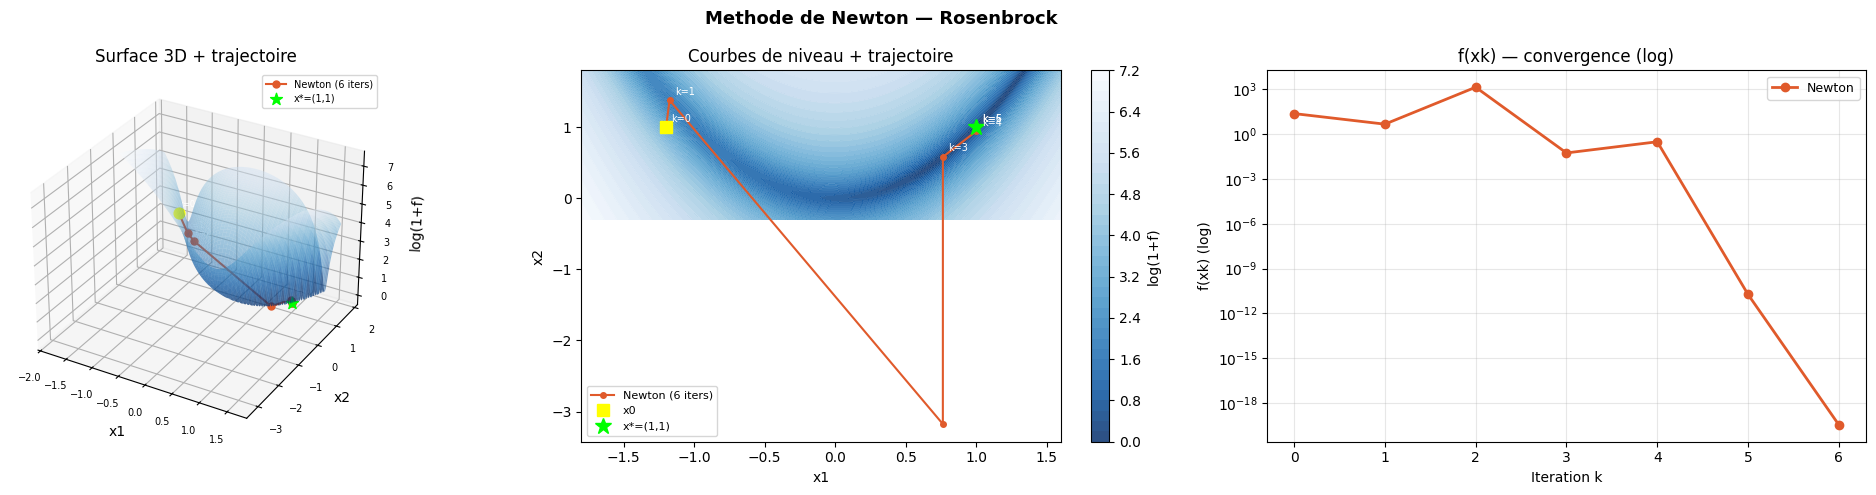

In [7]:
# --- Fonction test : Rosenbrock ---
f_rb    = lambda x: (1-x[0])**2 + 100*(x[1]-x[0]**2)**2
grad_rb = lambda x: np.array([
    -2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2),
     200*(x[1]-x[0]**2)
])
hess_rb = lambda x: np.array([
    [2 - 400*(x[1] - x[0]**2) + 800*x[0]**2,  -400*x[0]],
    [-400*x[0],                                  200.0    ]
])

x0 = np.array([-1.2, 1.0])
x_star, trajectory = newton(f_rb, grad_rb, hess_rb, x0)
trajectory = np.array(trajectory)
f_vals = [f_rb(x) for x in trajectory]

print(f"Newton : {len(trajectory)-1} iterations, x* = {x_star}")

# --- Grille Rosenbrock ---
r1 = np.linspace(-1.8, 1.6, 200)
r2 = np.linspace(-0.3, 1.8, 200)
R1, R2 = np.meshgrid(r1, r2)
Z_rb = (1-R1)**2 + 100*(R2-R1**2)**2

fig = plt.figure(figsize=(20, 5))
fig.suptitle("Methode de Newton — Rosenbrock", fontsize=13, fontweight="bold")

# --- Subplot 1 : surface 3D ---
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.plot_surface(R1, R2, np.log1p(Z_rb), cmap="Blues_r", alpha=0.5, linewidth=0)
tz = np.log1p(np.array([f_rb(x) for x in trajectory]))
ax1.plot(trajectory[:,0], trajectory[:,1], tz, "o-", color="#e05a2b", lw=1.5, ms=5,
         label=f"Newton ({len(trajectory)-1} iters)")
ax1.scatter([x0[0]], [x0[1]], [tz[0]], color="yellow", s=60, zorder=6)
ax1.scatter([1], [1], [0], color="lime", s=80, marker="*", zorder=6, label="x*=(1,1)")
for k, (xk, zk) in enumerate(zip(trajectory, tz)):
    ax1.text(xk[0], xk[1], zk + 0.3, f"k={k}", fontsize=6, color="white")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2"); ax1.set_zlabel("log(1+f)")
ax1.set_title("Surface 3D + trajectoire"); ax1.legend(fontsize=7); ax1.tick_params(labelsize=7)

# --- Subplot 2 : courbes de niveau ---
ax2 = fig.add_subplot(1, 3, 2)
cp = ax2.contourf(R1, R2, np.log1p(Z_rb), levels=40, cmap="Blues_r", alpha=0.85)
ax2.contour(R1, R2, np.log1p(Z_rb), levels=40, colors="white", linewidths=0.3, alpha=0.35)
plt.colorbar(cp, ax=ax2, label="log(1+f)")
ax2.plot(trajectory[:,0], trajectory[:,1], "o-", color="#e05a2b", lw=1.5, ms=4,
         label=f"Newton ({len(trajectory)-1} iters)")
for k, xk in enumerate(trajectory):
    ax2.annotate(f"k={k}", (xk[0], xk[1]), textcoords="offset points",
                 xytext=(4, 4), fontsize=7, color="white")
ax2.plot(x0[0], x0[1], "s", color="yellow", ms=9, label="x0")
ax2.plot(1, 1, "*", color="lime", ms=12, label="x*=(1,1)")
ax2.set_title("Courbes de niveau + trajectoire")
ax2.set_xlabel("x1"); ax2.set_ylabel("x2"); ax2.legend(fontsize=8)

# --- Subplot 3 : convergence ---
ax3 = fig.add_subplot(1, 3, 3)
ax3.semilogy(range(len(f_vals)), f_vals, "o-", color="#e05a2b", lw=2, label="Newton")
ax3.set_title("f(xk) — convergence (log)")
ax3.set_xlabel("Iteration k"); ax3.set_ylabel("f(xk) (log)")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
def quasi_newton_bfgs(
    f: Callable[[NDArray[np.float64]], float],
    grad_f: Callable[[NDArray[np.float64]], NDArray[np.float64]],
    x0: NDArray[np.float64],
    alpha: float = 0.3,
    beta: float = 0.4,
    tol: float = 1e-6,
    max_iter: int = 1000
) -> tuple[NDArray[np.float64], list[NDArray[np.float64]]]:

    n = len(x0)
    x_current = x0.copy().astype(float)
    gradient_current = grad_f(x_current)

    hessian_inv_approx = np.eye(n)

    trajectory = [x_current.copy()]

    while True:
        if np.linalg.norm(gradient_current) < tol:
            break
        if len(trajectory) > max_iter:
            break

        direction = -hessian_inv_approx @ gradient_current

        step_size = armijo(f, gradient_current, x_current, direction, alpha, beta)

        x_next = x_current + step_size * direction
        gradient_next = grad_f(x_next)

        sk = x_next - x_current
        yk = gradient_next - gradient_current

        sy = sk @ yk

        if abs(sy) > 1e-12:
            rho = 1.0 / sy
            I = np.eye(n)
            A = I - rho * np.outer(sk, yk)
            B = I - rho * np.outer(yk, sk)
            hessian_inv_approx = A @ hessian_inv_approx @ B + rho * np.outer(sk, sk)

        x_current = x_next
        gradient_current = gradient_next
        trajectory.append(x_current.copy())

    return x_current, trajectory

BFGS : 34 iterations, x* = [1. 1.]


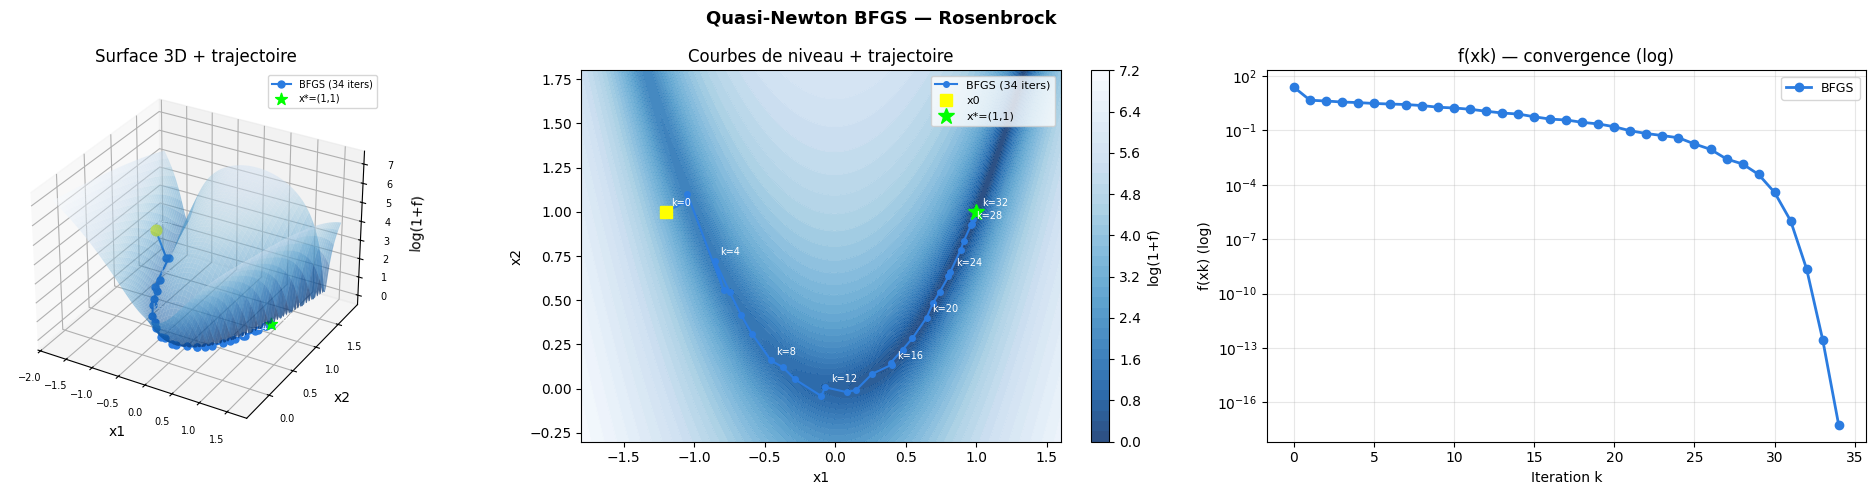

In [9]:
# --- Fonction test : Rosenbrock ---
f_rb    = lambda x: (1-x[0])**2 + 100*(x[1]-x[0]**2)**2
grad_rb = lambda x: np.array([
    -2*(1-x[0]) - 400*x[0]*(x[1]-x[0]**2),
     200*(x[1]-x[0]**2)
])

x0 = np.array([-1.2, 1.0])
x_star, trajectory = quasi_newton_bfgs(f_rb, grad_rb, x0)
trajectory = np.array(trajectory)
f_vals = [f_rb(x) for x in trajectory]

print(f"BFGS : {len(trajectory)-1} iterations, x* = {x_star}")

# --- Grille Rosenbrock ---
r1 = np.linspace(-1.8, 1.6, 200)
r2 = np.linspace(-0.3, 1.8, 200)
R1, R2 = np.meshgrid(r1, r2)
Z_rb = (1-R1)**2 + 100*(R2-R1**2)**2

fig = plt.figure(figsize=(20, 5))
fig.suptitle("Quasi-Newton BFGS — Rosenbrock", fontsize=13, fontweight="bold")

# --- Subplot 1 : surface 3D ---
ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.plot_surface(R1, R2, np.log1p(Z_rb), cmap="Blues_r", alpha=0.5, linewidth=0)
tz = np.log1p(np.array([f_rb(x) for x in trajectory]))
ax1.plot(trajectory[:,0], trajectory[:,1], tz, "o-", color="#2b7ce0", lw=1.5, ms=5,
         label=f"BFGS ({len(trajectory)-1} iters)")
ax1.scatter([x0[0]], [x0[1]], [tz[0]], color="yellow", s=60, zorder=6)
ax1.scatter([1], [1], [0], color="lime", s=80, marker="*", zorder=6, label="x*=(1,1)")
for k, (xk, zk) in enumerate(zip(trajectory, tz)):
    if k % max(1, len(trajectory)//8) == 0:
        ax1.text(xk[0], xk[1], zk + 0.3, f"k={k}", fontsize=6, color="white")
ax1.set_xlabel("x1"); ax1.set_ylabel("x2"); ax1.set_zlabel("log(1+f)")
ax1.set_title("Surface 3D + trajectoire"); ax1.legend(fontsize=7); ax1.tick_params(labelsize=7)

# --- Subplot 2 : courbes de niveau ---
ax2 = fig.add_subplot(1, 3, 2)
cp = ax2.contourf(R1, R2, np.log1p(Z_rb), levels=40, cmap="Blues_r", alpha=0.85)
ax2.contour(R1, R2, np.log1p(Z_rb), levels=40, colors="white", linewidths=0.3, alpha=0.35)
plt.colorbar(cp, ax=ax2, label="log(1+f)")
ax2.plot(trajectory[:,0], trajectory[:,1], "o-", color="#2b7ce0", lw=1.5, ms=4,
         label=f"BFGS ({len(trajectory)-1} iters)")
for k, xk in enumerate(trajectory):
    if k % max(1, len(trajectory)//8) == 0:
        ax2.annotate(f"k={k}", (xk[0], xk[1]), textcoords="offset points",
                     xytext=(4, 4), fontsize=7, color="white")
ax2.plot(x0[0], x0[1], "s", color="yellow", ms=9, label="x0")
ax2.plot(1, 1, "*", color="lime", ms=12, label="x*=(1,1)")
ax2.set_title("Courbes de niveau + trajectoire")
ax2.set_xlabel("x1"); ax2.set_ylabel("x2"); ax2.legend(fontsize=8)

# --- Subplot 3 : convergence ---
ax3 = fig.add_subplot(1, 3, 3)
ax3.semilogy(range(len(f_vals)), f_vals, "o-", color="#2b7ce0", lw=2, label="BFGS")
ax3.set_title("f(xk) — convergence (log)")
ax3.set_xlabel("Iteration k"); ax3.set_ylabel("f(xk) (log)")
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()